# Maternal Morbidity State Analysis

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## State Heatmaps 

In [3]:
def load_and_clean(path):
    """Load a raw WONDER export, keeping only rows with a real state
    and a usable (non-suppressed) morbidity category."""
    df = pd.read_csv(path, dtype=str, engine="python", on_bad_lines="skip")
    df["Births"] = pd.to_numeric(df["Births"], errors="coerce")
    df = df[df["State of Residence"].notna() & df["Births"].notna()]
    df = df[df["Maternal Morbidity Checked"].isin(["At least one checked", "None checked"])]
    return df

df1 = load_and_clean("q1_cdc_wonder.csv")
df2 = load_and_clean("q2_cdc_wonder.csv")

def state_rate(df):
    """Collapse a row-level file down to one morbidity rate per state,
    regardless of which other variables (race/age/education, or
    urbanicity/hispanic/insurance) it was broken out by."""
    r = df.groupby(["State of Residence", "Maternal Morbidity Checked"])["Births"].sum().unstack(fill_value=0)
    r["total"] = r["At least one checked"] + r["None checked"]
    r["rate"] = r["At least one checked"] / r["total"]
    return r["rate"]

rate1 = state_rate(df1).rename("morbidity_rate_q1")
rate2 = state_rate(df2).rename("morbidity_rate_q2")

# pd.concat with axis=1 lines these two Series up by their shared index
# (State of Residence), giving one row per state with both rates side by side
combined = pd.concat([rate1, rate2], axis=1)
combined["morbidity_rate_combined"] = combined.mean(axis=1)
combined = combined.reset_index()

print(combined.round(5))
combined.to_csv("five_state_morbidity_combined.csv")

  State of Residence  morbidity_rate_q1  morbidity_rate_q2  \
0            Alabama            0.01198            0.01345   
1         California            0.01299            0.01332   
2           Nebraska            0.01529            0.01852   
3      New Hampshire            0.02575            0.03014   
4              Texas            0.00852            0.00876   

   morbidity_rate_combined  
0                  0.01271  
1                  0.01315  
2                  0.01691  
3                  0.02795  
4                  0.00864  


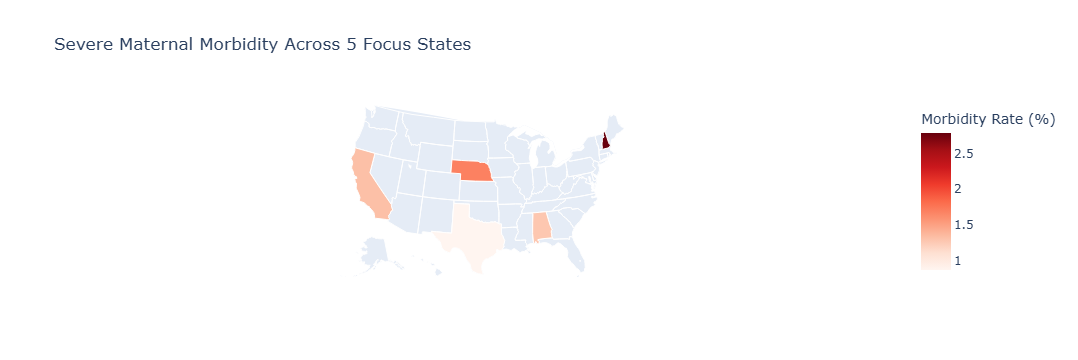

In [4]:
df = pd.read_csv("five_state_morbidity_combined.csv")

state_abbrev = {"Texas": "TX", "California": "CA", "New Hampshire": "NH",
                 "Alabama": "AL", "Nebraska": "NE"}
df["abbrev"] = df["State of Residence"].map(state_abbrev)

fig = go.Figure(data=go.Choropleth(
    locations=df["abbrev"],
    z=df["morbidity_rate_combined"] * 100,
    locationmode="USA-states",
    colorscale="Reds",
    colorbar_title="Morbidity Rate (%)",
    marker_line_color="white",
))
fig.update_layout(title_text="Severe Maternal Morbidity Across 5 Focus States", geo_scope="usa")
fig.show()

## Logistic Regression

In [5]:
def load_and_clean(path):
    df = pd.read_csv(path, dtype=str, engine="python", on_bad_lines="skip")
    df["Births"] = pd.to_numeric(df["Births"], errors="coerce")
    df = df[df["State of Residence"].notna() & df["Births"].notna()]
    df = df[df["Maternal Morbidity Checked"].isin(["At least one checked", "None checked"])]
    return df

my_states = ["Texas", "California", "New Hampshire", "Alabama", "Nebraska"]
df1 = load_and_clean("q1_cdc_wonder.csv")  # <- make sure this filename matches what you uploaded
df1["y"] = (df1["Maternal Morbidity Checked"] == "At least one checked").astype(int)
feature_cols = ["Mother's Single Race 6", "Age of Mother 10", "Mother's Education"]

X_all_dummies = pd.get_dummies(df1[feature_cols], drop_first=True)

In [6]:
results = {}
for state in my_states:
    mask = df1["State of Residence"] == state
    X_state = X_all_dummies[mask]
    y_state = df1.loc[mask, "y"]

    valid_cols = X_state.columns[X_state.nunique() > 1]
    X_state = X_state[valid_cols]

    logit = LogisticRegression(max_iter=3000)
    logit.fit(X_state, y_state)
    results[state] = pd.Series(logit.coef_[0], index=valid_cols)

coef_by_state = pd.DataFrame(results)

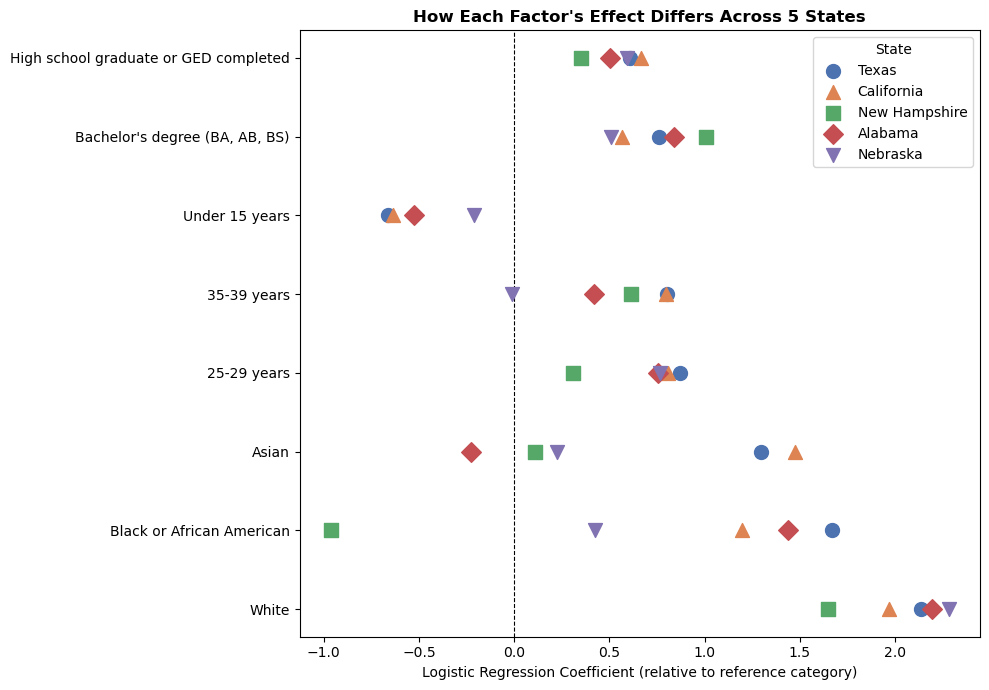

In [7]:
key_vars = [
    "Mother's Single Race 6_White",
    "Mother's Single Race 6_Black or African American",
    "Mother's Single Race 6_Asian",
    "Age of Mother 10_25-29 years",
    "Age of Mother 10_35-39 years",
    "Age of Mother 10_Under 15 years",
    "Mother's Education_Bachelor's degree (BA, AB, BS)",
    "Mother's Education_High school graduate or GED completed",
]
subset = coef_by_state.loc[[v for v in key_vars if v in coef_by_state.index]]

states = subset.columns.tolist()
markers = ['o', '^', 's', 'D', 'v']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(10, 7))
y_positions = np.arange(len(subset))

for i, state in enumerate(states):
    ax.scatter(subset[state], y_positions, marker=markers[i], color=colors[i], s=100, label=state, zorder=3)

ax.set_yticks(y_positions)
ax.set_yticklabels([v.split("_", 1)[1] for v in subset.index])
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Logistic Regression Coefficient (relative to reference category)")
ax.set_title("How Each Factor's Effect Differs Across 5 States", fontweight="bold")
ax.legend(title="State", loc="best")
plt.tight_layout()
plt.savefig("per_state_comparison_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## OLS regression

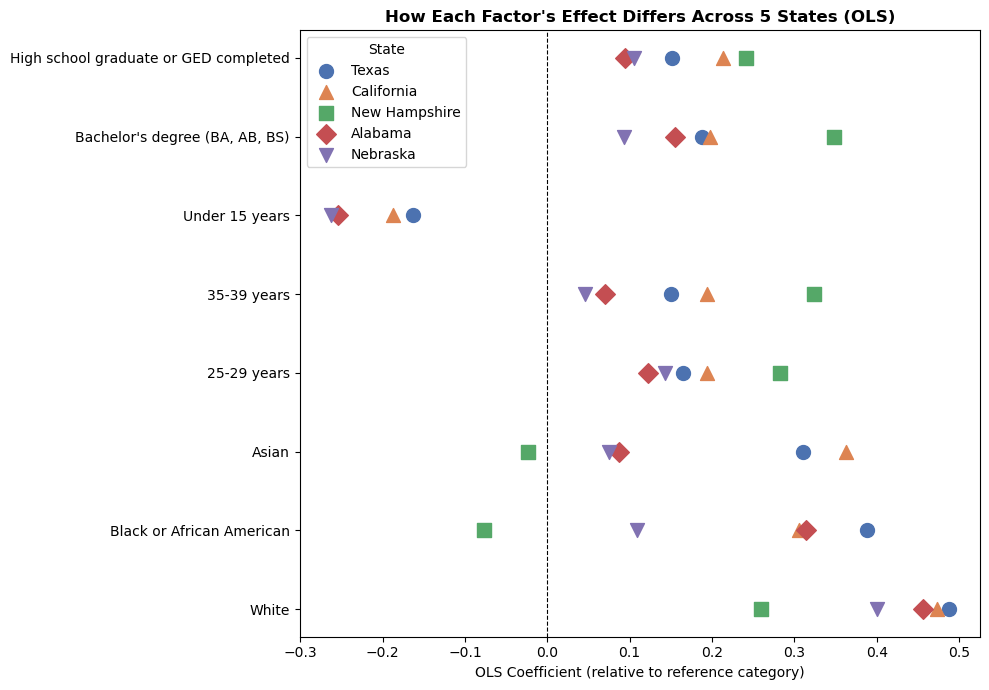

In [8]:
def load_and_clean(path):
    df = pd.read_csv(path, dtype=str, engine="python", on_bad_lines="skip")
    df["Births"] = pd.to_numeric(df["Births"], errors="coerce")
    df = df[df["State of Residence"].notna() & df["Births"].notna()]
    df = df[df["Maternal Morbidity Checked"].isin(["At least one checked", "None checked"])]
    return df

my_states = ["Texas", "California", "New Hampshire", "Alabama", "Nebraska"]
df1 = load_and_clean("q1_cdc_wonder.csv")
df1["y"] = (df1["Maternal Morbidity Checked"] == "At least one checked").astype(int)
feature_cols = ["Mother's Single Race 6", "Age of Mother 10", "Mother's Education"]
X_all_dummies = pd.get_dummies(df1[feature_cols], drop_first=True)

results = {}
for state in my_states:
    mask = df1["State of Residence"] == state
    X_state = X_all_dummies[mask]
    y_state = df1.loc[mask, "y"]
    valid_cols = X_state.columns[X_state.nunique() > 1]
    X_state = X_state[valid_cols]

    ols = LinearRegression()
    ols.fit(X_state, y_state)
    results[state] = pd.Series(ols.coef_, index=valid_cols)

coef_by_state = pd.DataFrame(results)

key_vars = [
    "Mother's Single Race 6_White",
    "Mother's Single Race 6_Black or African American",
    "Mother's Single Race 6_Asian",
    "Age of Mother 10_25-29 years",
    "Age of Mother 10_35-39 years",
    "Age of Mother 10_Under 15 years",
    "Mother's Education_Bachelor's degree (BA, AB, BS)",
    "Mother's Education_High school graduate or GED completed",
]
subset = coef_by_state.loc[[v for v in key_vars if v in coef_by_state.index]]

states = subset.columns.tolist()
markers = ['o', '^', 's', 'D', 'v']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(10, 7))
y_positions = np.arange(len(subset))
for i, state in enumerate(states):
    ax.scatter(subset[state], y_positions, marker=markers[i], color=colors[i], s=100, label=state, zorder=3)

ax.set_yticks(y_positions)
ax.set_yticklabels([v.split("_", 1)[1] for v in subset.index])
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("OLS Coefficient (relative to reference category)")
ax.set_title("How Each Factor's Effect Differs Across 5 States (OLS)", fontweight="bold")
ax.legend(title="State", loc="best")
plt.tight_layout()
plt.savefig("per_state_comparison_chart_OLS.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
my_states = ["Texas", "California", "New Hampshire", "Alabama", "Nebraska"]
df5 = load_and_clean("q1_cdc_wonder.csv")  # your 5-state file
df5["y"] = (df5["Maternal Morbidity Checked"] == "At least one checked").astype(int)

X_all_dummies = pd.get_dummies(df5[feature_cols], drop_first=True)

results_weighted = {}
for state in my_states:
    mask = df5["State of Residence"] == state
    X_state = X_all_dummies[mask]
    y_state = df5.loc[mask, "y"]
    w_state = df5.loc[mask, "Births"]  # population weight

    valid_cols = X_state.columns[X_state.nunique() > 1]
    X_state = X_state[valid_cols]

    ols = LinearRegression()
    ols.fit(X_state, y_state, sample_weight=w_state)
    results_weighted[state] = pd.Series(ols.coef_, index=valid_cols)

coef_weighted = pd.DataFrame(results_weighted)
print(coef_weighted.round(4))

                                                                                         Texas  \
Age of Mother 10_18 - 19 years                                                         -0.0012   
Age of Mother 10_20-24 years                                                           -0.0025   
Age of Mother 10_25-29 years                                                           -0.0036   
Age of Mother 10_30-34 years                                                           -0.0040   
Age of Mother 10_35-39 years                                                           -0.0037   
Age of Mother 10_40-44 years                                                           -0.0041   
Age of Mother 10_45-49 years                                                           -0.0128   
Age of Mother 10_50 years and over                                                     -0.0130   
Age of Mother 10_Under 15 years                                                        -0.0122   
Mother's Education_9

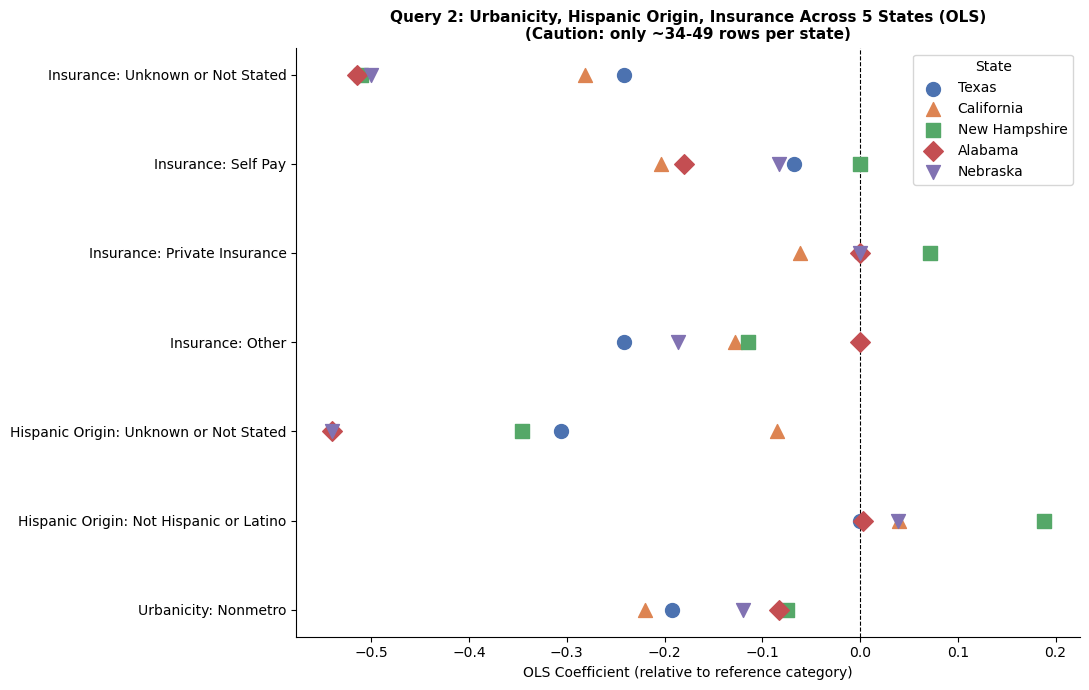

In [12]:
coef2 = pd.read_csv("per_state_coefficients_OLS_query2.csv", index_col=0)
coef2 = coef2.sort_index()

# Map each column's PREFIX (before the first underscore) to a short,
# readable variable name -- this is what was getting silently dropped before
prefix_map = {
    "2023 Metro/Nonmetro": "Urbanicity",
    "Mother's Hispanic Origin": "Hispanic Origin",
    "Source of Payment for Delivery": "Insurance",
}

def make_label(full_name):
    for prefix, short_name in prefix_map.items():
        if full_name.startswith(prefix + "_"):
            category = full_name[len(prefix) + 1:]  # everything after "Prefix_"
            return f"{short_name}: {category}"
    return full_name  # fallback, shouldn't hit this if prefix_map covers everything

labels = [make_label(v) for v in coef2.index]

states = coef2.columns.tolist()
markers = ['o', '^', 's', 'D', 'v']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(11, 7))
y_positions = np.arange(len(coef2))
for i, state in enumerate(states):
    ax.scatter(coef2[state], y_positions, marker=markers[i], color=colors[i], s=100, label=state, zorder=3)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)  # <-- now uses the disambiguated labels
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("OLS Coefficient (relative to reference category)")
ax.set_title("Query 2: Urbanicity, Hispanic Origin, Insurance Across 5 States (OLS)\n(Caution: only ~34-49 rows per state)",
             fontweight="bold", fontsize=11)
ax.legend(title="State", loc="best")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("per_state_comparison_chart_OLS_query2.png", dpi=200, bbox_inches="tight")
plt.show()